# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RayTraceFunctions as rt
from sklearn.cluster import KMeans

import yaml
import time
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio; pio.renderers.default='notebook' # 'browser'
import coupling_optics_sims as csims
import interferogram_fitting
import seaborn as sns
import utils

/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:255: RuntimeWarning:

invalid value encountered in sqrt



# Definitions for Plotting

In [2]:
def step_rays(starting_rays, config, ray_func, *ray_func_args, final_dist=50, 
              debug=1, return_pol_angles=False):
    # Data structure which contains starting point, vector, length for each ray
    # through the sim
    total_ray_points = []
    total_ray_vectors = []
    total_ray_distances = []
    total_pol_angles = []
    counts = []
    max_count = None

    for starting_ray in starting_rays:
        current_rays = ray_func(
            starting_ray, *ray_func_args, return_all_rays=True)
        # We want to save the point, vector, and distance travelled for each of
        # these rays!
        points = []
        vectors = []
        distances = [starting_ray[4]]
        pol_angles = []
        count = 0
        max_count = len(current_rays) + 1
        for i, ray in enumerate(current_rays):
            if ray is not None:
                count += 1
                points.append(ray[2])
                vectors.append(ray[3])
                pol_angles.append(ray[0])

                # If we're not at the final ray and the next ray hit,
                # calculated the distance!
                if (i < len(current_rays) - 1):
                    if current_rays[i + 1] is not None:
                        distances.append(
                            current_rays[i + 1][4] - current_rays[i][4])
                else:
                    # The ray made it to the last detector; give it some
                    # smaller distance to visualize.
                    final_ray = rt.get_final_rays_tilt(
                        [ray], config['detector']['center'], config['detector']['range'],
                        config['detector']['normal_vec'])
                    if (final_ray) != []:
                        distances.append(rt.dist(ray[2], final_ray[0][2]))
                        count += 1

                    else:
                        distances.append(final_dist)

                    # distances.append(final_dist)
            else:
                # The ray did not make it to the end.
                # Append a final distance for the last ray so we can see where
                # it went.
                distances.append(final_dist)

        total_ray_points.append(points)
        total_ray_vectors.append(vectors)
        total_ray_distances.append(distances)
        total_pol_angles.append(pol_angles)
        counts.append(count)

    assert debug in [0, 1, 2]
    if (debug == 2):
        print('final ray counts = %s' % counts)
    if (debug == 1):
        print('initial number of rays = %s' % len(starting_rays))
        print('total number of rays making past the first ellipse = %s' % np.sum(
            np.array(counts) != 1))
        print('total number of rays making it all the way through = %s' % np.sum(
            np.array(counts) == max_count))
    if return_pol_angles:
        return total_ray_points, total_ray_vectors, total_ray_distances, total_pol_angles
    return total_ray_points, total_ray_vectors, total_ray_distances

def plot_all_items(config, all_points, all_vectors, all_distances, mirror_position, fig=None, 
                   ray_alpha=None):
    if (fig is None):
        fig = go.Figure()

    # Plot the elliptical mirrors
    colors = 9 * ['silver']
    plot_mirrors(total_ellipse_points, colors, fig)

    # Plot the rays
    colors = ['black', 'black', 'red', 'red', 'orange', 'black', 'orange', 'yellow',
              'yellow', 'green', 'green', 'blue', 'blue', 'purple']
    colors = 14 * ['black']
    for points, vectors, distances in zip(all_points, all_vectors, all_distances):
        plot_rays(points, vectors, distances, colors, fig, ray_alpha=ray_alpha)

    # Plot the polarizers and 'detector'
    centers = [rt.get_aspect(config, 'origins', 'polarizers', i + 1) for i in range(4)]# + [
        #config['detector']['center']]# + np.array([0, -1, 0])]
    coeffs = [rt.get_aspect(config, 'coefficients', 'polarizers', i + 1)[:2] for i in range(4)]# + [
        #[config['detector']['range'], config['detector']['range']]]

    #coeffs = 4 * [coeffpolar[:2]]
    thicknesses = 4 * [.4]
    colors = 4 * ['teal']# + ['black']
    opacities = 4 * [.2]# + [.4]
    n_points = 100
    plot_center_items(fig, centers, coeffs, thicknesses, colors, opacities, n_points=n_points)

    # Plot the dihedral mirror
    coeff = coeffs[0]
    thickness = 1
    plot_dihedral(fig, mirror_position, coeff, thickness)


    # Update the figure settings
    fig.update_layout(scene = dict(#xaxis_title='Z (mm)', yaxis_title='Y (mm)',
                                   #zaxis_title='X (mm)',
                        yaxis=dict(range=[-1000, 500]),
                        zaxis=dict(range=[-300, 300]),
                        xaxis=dict(range=[-1000, 500])),
                      width=700)#,
                      #margin=dict(r=20, b=10, l=10, t=10))


    #fig.show()
    
def plot_mirrors(total_points, colors, fig):
    for i, points in enumerate(total_points):
        half_index = len(points[0]) // 2
        x1, y1, z1 = [points[j][:half_index] for j in range(len(points))]
        x2, y2, z2 = [points[j][half_index:] for j in range(len(points))]

        mesh1 = go.Mesh3d(x=x1, y=y1, z=z1, color=colors[i], opacity=0.50)
        mesh2 = go.Mesh3d(x=x2, y=y2, z=z2, color=colors[i], opacity=0.50)

        fig.add_trace(mesh1)
        fig.add_trace(mesh2)
        
        
def plot_rays(total_ray_points, total_ray_vectors, total_ray_distances, colors,
              fig, ray_alpha=None):
    for i in range(len(total_ray_points)):
        for j, point in enumerate(total_ray_points[i]):
            vector = total_ray_vectors[i][j]
            distance = total_ray_distances[i][j + 1]
            x, y, z = [[point[k], point[k] + distance * vector[k]] for k in range(3)]
            #print(colors)
            if ray_alpha is None:
                ray_alpha = .5
            line_data = go.Scatter3d(
                x=x, y=y, z=z, mode='lines', showlegend=False, line=dict(
                    color=colors[j]), opacity=ray_alpha)#, dash='solid')
            fig.add_trace(line_data)
            
def plot_center_items(fig, centers, coeffs, thicknesses, colors, opacities, n_points=1000):
    for i in range(len(centers)):
        # We want to find this ellipse over x and y here..
        x_vals, y_vals, z1_vals, z2_vals = [], [], [], []
        x, z1, z2 = get_2d_ellipse(coeffs[i], (centers[i][0], centers[i][2]), n_points=n_points)
        for y in np.linspace(centers[i][1] - thicknesses[i], centers[i][1] + thicknesses[i], 10):
            x_vals.extend(x)
            z1_vals.extend(z1)
            z2_vals.extend(z2)
            y_vals.extend(n_points * [y])

        side1 = go.Mesh3d(x=x_vals, y=y_vals, z=z1_vals, color=colors[i], opacity=opacities[i]) 
        side2 = go.Mesh3d(x=x_vals, y=y_vals, z=z2_vals, color=colors[i], opacity=opacities[i])
        fig.add_trace(side1)
        fig.add_trace(side2)
        
def get_2d_ellipse(coeffs, center, n_points=1000):
    # assume no rotation here for simplicity
    # equation is (x - h)^2 / a^2 + (y - k)^2 / b^2 = 1
    assert len(center) == 2
    x_coeff, y_coeff = coeffs
    
    # First give a range of x values
    x_vals = np.linspace(-x_coeff, x_coeff, n_points) + center[0]
    # have to plot two y function to combine to the circle
    y1 = (np.sqrt(1 - ((x_vals - center[0]) / x_coeff)  ** 2)) * y_coeff + center[1]
    y2 = -(np.sqrt(1 - ((x_vals - center[0]) / x_coeff)  ** 2)) * y_coeff + center[1]
    
    return x_vals, y1, y2

def plot_dihedral(fig, center, coeff, thickness):
    # We want to find this ellipse over x and z here
    x_vals, y_vals, z1_vals, z2_vals = [], [], [], []
    x, z1, z2 = get_2d_ellipse(coeff, (center[0], center[2]), n_points=1000)
    for y in np.linspace(-1 * thickness, thickness, 10):
        x_vals.extend(x)
        z1_vals.extend(z1)
        z2_vals.extend(z2)
        y_vals.extend(1000 * [y]) 

    # Rotate both parts around the x axis
    for theta in [[np.pi / 4, 0, 0], [-np.pi / 4, 0, 0]]:
        p1s, p2s = rotate_ellipse(x_vals, y_vals, z1_vals, z2_vals, theta)
        x1, y1, z1 = p1s
        x2, y2, z2 = p2s

        side1 = go.Mesh3d(x=x1, y=np.array(y1) + center[1], z=z1, color='blue', opacity=.25) 
        side2 = go.Mesh3d(x=x2, y=np.array(y2) + center[1], z=z2, color='blue', opacity=.25)
        fig.add_trace(side1)
        fig.add_trace(side2)

def rotate_ellipse(xvals, yvals, z1_vals, z2_vals, theta):
    points_new = []
    for zvals in [z1_vals, z2_vals]:
        points = rt.transformLG(xvals, yvals, zvals, [0, 0, 0], theta)
        points_new.append(points)
    return points_new

LAST_LENS_EDGE = [-231.24377979, -266.21940725, 0.] 
COUPLING_OPTICS_ORIGIN = [-233.28894593160666, -276.84436350628596, 0.]

with open("20260223_fts_dims.yaml", "r") as stream:
    config = yaml.safe_load(stream)

# Create mesh of ellipse points to plot

In [3]:
def get_ranges_and_global_coords(n, angle, ellipse_coeffs, length, direc,
                                 origin, theta, rad):
    assert direc in ['pos', 'neg']
    x1, y1, z1, x2, y2, z2 = rt.FTSEC(n, angle, ellipse_coeffs, length, direc)

    def get_half_ranges(rad, xvals, yvals, zvals):
        x_global, y_global, z_global = rt.transformLG(xvals, yvals, zvals, origin,
                                                   theta)
        xset, yset, zset = rt.SR2(rad, x_global, y_global, z_global, origin)
        return xset, yset, zset

    xg1, yg1, zg1 = get_half_ranges(rad, x1, y1, z1)
    xg2, yg2, zg2 = get_half_ranges(rad, x2, y2, z2)
    center, range_vals = rt.xrangeGL7(xg1, yg1, zg1, xg2, yg2, zg2, origin, theta)
    xg1.extend(xg2)
    yg1.extend(yg2)
    zg1.extend(zg2)
    return center, range_vals, [xg1, yg1, zg1]

n_val = 100
angle = np.pi / 8
length = 90
rad_val = rt.get_aspect(config, 'coefficients', 'polarizers', 0)[0]
num_ellipse = [1, 2, 3, 4, 5, 6, 8, 9]

total_ellipse_centers = []
total_ellipse_ranges = []
total_ellipse_points = []

# For plottng ellipses
for i, num in enumerate(num_ellipse): 
    origin = rt.get_aspect(config, 'origins', 'ellipses', num)
    direc = ['pos', 'neg'][origin[1] > 0]
    theta = rt.get_aspect(config, 'angles', 'ellipses', num)
    coeffs = rt.get_aspect(config, 'coefficients', 'ellipses', num)

    center, range_vals, points = get_ranges_and_global_coords(
        n_val, angle, coeffs, length, direc, origin, theta, rad_val)

    total_ellipse_centers.append(center)
    total_ellipse_ranges.append(range_vals)
    total_ellipse_points.append(points)

# Raytracing Features

## Example Raytrace through the FTS

In [4]:
x_disp = 0
y_disp = 0

# Use uniform rays in theta and phi to better visualize.
starting_rays = utils.create_source_rays_uniform_from_start_displacement(
    config['source']['center'], config['source']['normal_vec'], x_disp, 
    y_disp, 2, 5, config, theta_bound=0.06, check_rays=False, 
    timeout=100)

mirror_y = 10
mirror_position = [0, mirror_y, 0]
possible_paths = [path[::-1] for path in rt.get_possible_paths()]
# only do the 1st and 5th of these paths
possible_paths = [possible_paths[1], possible_paths[5]]
final_rays = rt.run_rays_through_sim(
    starting_rays, config, np.array(config['origins']['mirror']) + np.array(
        mirror_position), paths=possible_paths)

transformed_rays = utils.transform_rays_to_coupling_optics_frame(final_rays, config)

# plot the initial ray steps- not used in actual computations, but good for visualization.
all_points = []
all_vectors = []
all_distances = []
for path in possible_paths:
    total_ray_points, total_vectors, total_distances = step_rays(
        starting_rays, config, rt.run_ray_through_sim, config, mirror_position, 
        path, final_dist=0, debug=True)

    all_points.append(total_ray_points)
    all_vectors.append(total_vectors)
    all_distances.append(total_distances)
    
fig = go.Figure()
plot_all_items(config, all_points, all_vectors, all_distances, mirror_position,
               fig=fig, ray_alpha=.2)

out_forwards = csims.run_rays_forwards_input_rays(
    transformed_rays, z_ap=csims.FOCUS[2] + .65, plot=True, fig=fig, color='black', config=config)
fig.update_layout(scene = dict(
    yaxis=dict(range=[-1000, 500]),
    zaxis=dict(range=[-300, 300]),
    xaxis=dict(range=[-1300, 500])), width=2000)
fig.show()


initial number of rays = 10
total number of rays making past the first ellipse = 10
total number of rays making it all the way through = 10
initial number of rays = 10
total number of rays making past the first ellipse = 10
total number of rays making it all the way through = 10


/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:255: RuntimeWarning:

invalid value encountered in sqrt

/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:252: RuntimeWarning:

invalid value encountered in sqrt



## Example of the frequency shift


Here I show an example of the frequency shift seen in our data. I will do this with a much quicker to run example which inspects the path length difference in the rays for a fixed central mirror position and roughly determines the frequency shift from that single point. Additionally, this example finds the shift with respect to the starting offset on the source. In actuality what matters is how the ray position is mapped at plane of the detector and segmented within the detection radius of a detector feed, although the level of shift found is fairly similar in both cases.

This function, given an initial starting position from which the rays disperse,
will trace the rays through the whole optical system given one central mirror
position:

In [5]:
def total_forward_raytrace(x_disp, y_disp, config, n_linear_theta=100, n_linear_phi=100, 
                           mirror_position=0):

    # change to using lambertian 
    starting_rays = utils.create_source_rays_lambertian(
        config['source']['center'], config['source']['normal_vec'], x_disp, 
        y_disp, n_linear_theta, n_linear_phi, config, theta_bound=np.pi / 2, 
        check_rays=True, timeout=100)

    possible_paths = [path[::-1] for path in rt.get_possible_paths()]
    final_rays = rt.run_rays_through_sim(
        starting_rays, config, list(np.add(np.array(config['origins']['mirror']), 
            [0, mirror_position, 0])), paths=possible_paths)

    transformed_rays = utils.transform_rays_to_coupling_optics_frame(final_rays, config)
    # The focus I initialled estimated is a little off
    out_forwards = csims.run_rays_forwards_input_rays(
        transformed_rays, z_ap=csims.FOCUS[2] + 0.65, plot=False, fig=fig, color='red')
    return out_forwards

In [6]:
# Only ~100 points around the circle to save on time. In my full analysis I chose 625.
x_vals, y_vals = utils.create_uniformly_spaced_points_circle(45, 100)

coords = []
pos = 20
total_out = []
for (x_start, y_start) in tqdm(zip(x_vals, y_vals)):
    # Use a ton of points in the theta direction since most of them end up missing the
    # initial aperture (already accounted for in the source generation).
    out_indiv = total_forward_raytrace(x_start, y_start, config, mirror_position=pos, 
                                       n_linear_theta=3000, n_linear_phi=15)
    total_out.append(out_indiv)

    coords.append((x_start, y_start))

0it [00:00, ?it/s]/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:255: RuntimeWarning:

invalid value encountered in sqrt

/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:252: RuntimeWarning:

invalid value encountered in sqrt

93it [05:33,  3.58s/it]


Let's take a look at what some of the path lengths are in the final rays.
Ideally for a perfect interferogram the two sides of light should have an equal
number of rays and there should be a very coherent path length difference
between the two equal to $4 h \cos(\theta) \approx 4 * d * (1 / 1.018)$

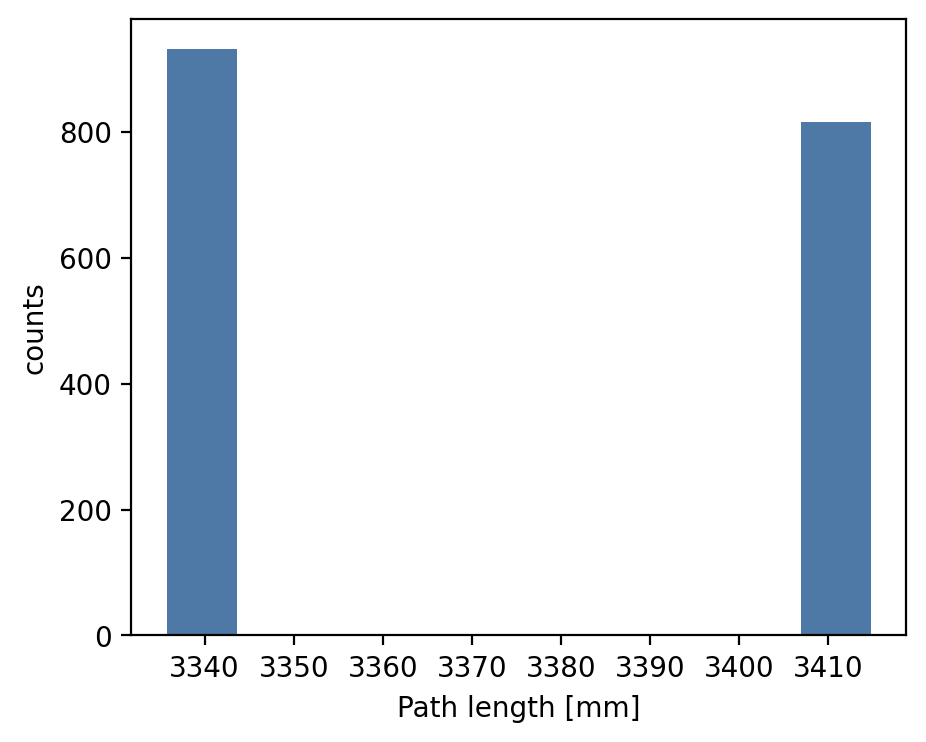

In [23]:
# Grab the 10th ray bundle's distances (there are 100 total bundles, one for each source point)
n = 10
plt.hist(total_out[n][8]) # distance is at the 8th index
plt.xlabel('Path length [mm]')
plt.ylabel('counts')
plt.show()


In actuality, we see that one of the two paths has fewer rays than the other
due to the central mirror position being offset causing wide angle rays to miss
for that path. However, although this will result in reduced amplitude for the
interferogram, it shouldn't affect the derived frequency as long as each path
has very coherent rays. Now, we can find a rough proxy for the frequency calibration by subtracting the path length difference betweeen the two groups and dividing by (4 * h), where h is the central mirror position


In [24]:
km = KMeans(n_clusters=2, n_init=10)
km.fit(total_out[n][8].reshape(-1, 1))
fac = 1 / (abs(np.diff(km.cluster_centers_[:, 0]))[0] / (4 * pos))
fac

1.0206763841445277

Now, let's look at the estimated frequency shift factor for every single source position:

In [25]:
facs = []
for indiv_out in total_out:
    km = KMeans(n_clusters=2, n_init=10)
    # remove some outlier points hit way too far away and are probably unphysically tracing from a lens boundary
    km.fit(utils.remove_outliers(indiv_out)[8].reshape(-1, 1))
    fac = 1 / (abs(np.diff(km.cluster_centers_[:, 0]))[0] / (4 * pos))
    facs.append(fac)

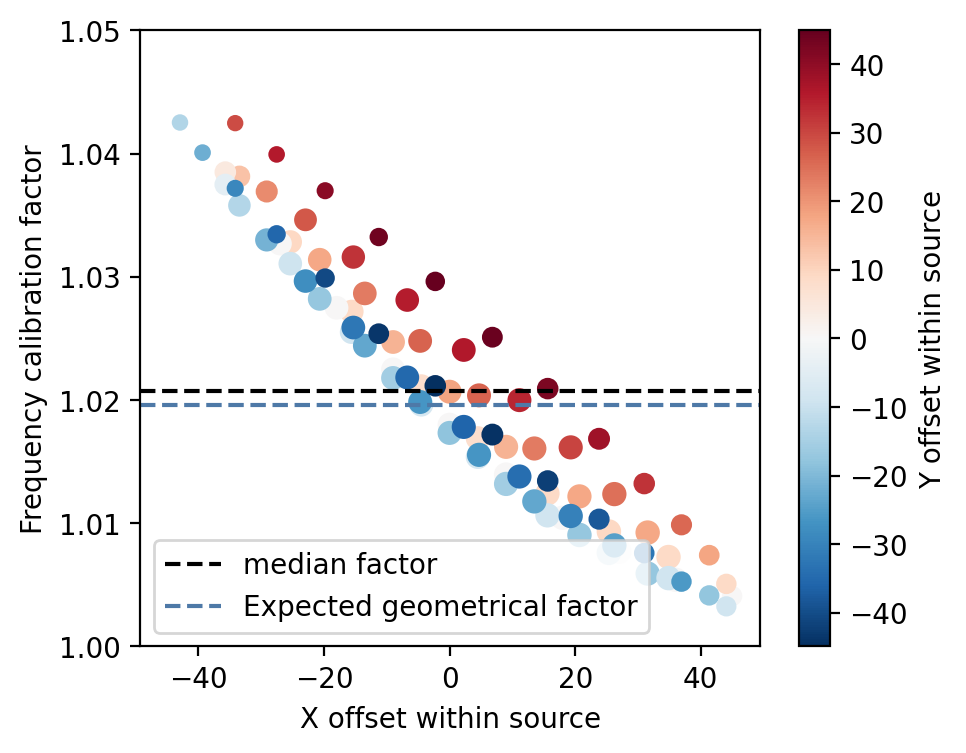

In [49]:
lens = np.array([t.shape[1] for t in total_out])
plt.scatter(np.array(coords)[:, 0], np.abs(facs), c=np.array(coords)[:, 1],
            cmap='RdBu_r', s=lens / 30)
plt.colorbar(label="Y offset within source")
# plt.xlim(-35, 35)

# There are some outliers due to some source points mostly missing the final detector. 
# Clipping the y range as a result, and using the median
mean_fac = np.mean(np.abs(facs)[np.abs(facs) < 2])
plt.axhline(mean_fac, label="median factor", color="black", ls="--")
plt.axhline(1.0196, label="Expected geometrical factor", ls="--")

plt.legend(loc='lower left')
plt.ylim(1, 1.05)
plt.xlabel('X offset within source')
plt.ylabel('Frequency calibration factor')
plt.show()

This gives you an estimation of the frequency shift effect we see and is a nice
quick way to estimate what shifts a given geometry will create without going
through a full raytrace through all possible interferogram positions, summing
the power, etc and segmenting within detector feeds.

## Creating a measured interferogram

Now, I will show a smaller more contained example of actually simulating
measured interferograms through this FTS system. I will choose an FTS throw of
20mm (yields a frequency resolution of ~2 GHz) and a step size of 0.1mm (max
frequency of ~380 GHz)


In [11]:
def trace_rays(start_displacement, config, n_mirror_positions, ymax, n_rays=100, 
               debug=False):
    starting_rays = utils.create_source_rays_lambertian_monte_carlo(
        config['source']['center'], config['source']['normal_vec'],
        start_displacement[0], start_displacement[1], n_rays,
        config, theta_bound=np.pi / 2, check_rays=True)

    # I originally described the possible paths through the FTS in reverse
    # also. Realistically I believe they should be symmetric for both forwards
    # and reverse, but originally I had some other operations in there which is
    # why I reverse them.
    possible_paths = [path[::-1] for path in rt.get_possible_paths()]

    # Propagate the source rays through the simulation (to the end of the FTS)
    # for all polarizer paths and central mirror positions.
    if debug:
        print("Tracing rays through the FTS...")
    delay, final_rays = rt.run_all_rays_through_sim_optimized(
        starting_rays, config, n_mirror_positions, paths=possible_paths,
        ymax=ymax, progressbar=(debug))

    total_outrays = []

    # Transform the rays to the frame of the coupling optics and propgate them
    # through this optical system.
    if debug:
        print("Tracing rays through the coupling optics...")
    for rays in tqdm(final_rays, disable=(not debug)):
        transformed_rays = utils.transform_rays_to_coupling_optics_frame(rays, config)
        out_forwards = csims.run_rays_forwards_input_rays(
            transformed_rays, z_ap=csims.FOCUS[2], plot=False)
        total_outrays.append(out_forwards)

    return total_outrays

In [12]:
FTS_stage_throw = 20.     # total throw extent in mm
FTS_stage_step_size = .1  # FTS step size in mm
n_mirror_positions = (2 * FTS_stage_throw / FTS_stage_step_size) + 1

out = trace_rays((0, 0), config, n_mirror_positions, FTS_stage_throw, debug=True,
                 n_rays=225)

Tracing rays through the FTS...


100%|███████████████████████████████████████████████████████████████████████████████| 401/401 [04:00<00:00,  1.67it/s]


Tracing rays through the coupling optics...


  0%|                                                                                         | 0/401 [00:00<?, ?it/s]/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:255: RuntimeWarning:

invalid value encountered in sqrt

/Users/talford/software/FTS_simulation_20260223/FTS-Simulation/fts_coupling_optics_geo.py:252: RuntimeWarning:

invalid value encountered in sqrt

100%|███████████████████████████████████████████████████████████████████████████████| 401/401 [11:01<00:00,  1.65s/it]


Here this interferogram is just for a starting point right at the center of our source, so we expect these rays to map to regions that near in the center of our detector plane also. Let's check this:

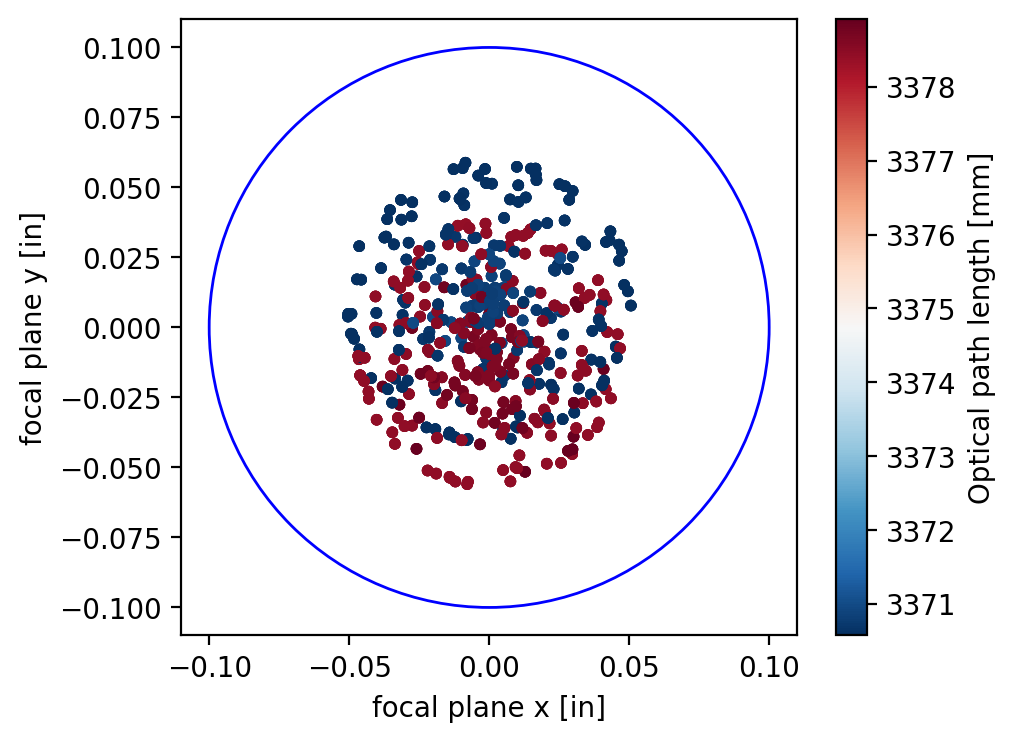

In [13]:
import matplotlib.patches as patches
# Plot rays from the 220th mirror position, 2mm off from center, to be able to slightly see the 
# two different paths from the central mirror
n = 220
z = csims.FOCUS[2] + 0.65
out_z = utils.get_rays_at_z(out[n], z) # My initial estimate for the focus was a little bit off
plt.scatter(out_z[0], out_z[1] - csims.FOCUS[1], c=out_z[8], s=10, alpha=1, 
           cmap="RdBu_r")
plt.colorbar(label="Optical path length [mm]")

# Plot the feed
circle = patches.Circle((0, 0), 0.10, edgecolor='blue', facecolor='none')
plt.gca().add_patch(circle)
plt.gca().set_aspect(1.0)

plt.xlabel('focal plane x [in]')
plt.ylabel('focal plane y [in]')
plt.show()

You can see that the rays are well focused right around the center of the detector plane. You can start to see two beams diverge which represents the two paths of light from different sides of the central mirror with different path lengths.

Now let's create the actual interferograms from ths:

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.19it/s]


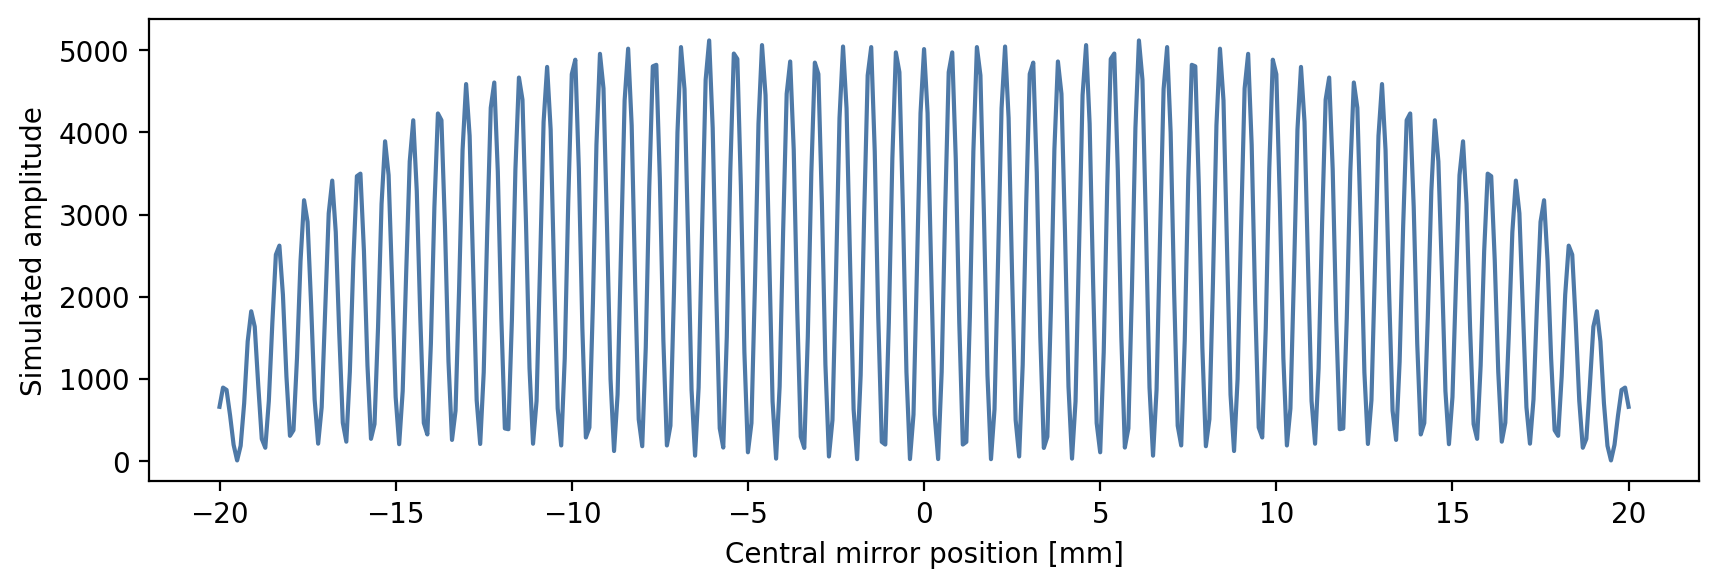

In [51]:
freq = 100
# segment detectors into a grid of 5x5 positions, where each detector has a feed size of 5.3mm 
# (ACT MF detectors)
# I know that the feed size is bigger than the detector spacing in this case, but here 
# the detector position is not trying to be physical, only a proxy for measuring the spatial 
# frequency shift vs position from focus
interferograms = np.sum(utils.get_and_combine_interferograms([out], [freq], 5, 5, 5.3, debug=True), axis=0)
mirror_positions = np.arange(-20, 20 + 0.1, 0.1)


plt.figure(figsize=(10, 3))
plt.xlabel('Central mirror position [mm]')
plt.ylabel('Simulated amplitude')
# Plot the interferogram corresponding to the (0, 0 position)
plt.plot(mirror_positions, interferograms[12])
plt.show()


Note that this code actually creates a 5x5 grid of possible detector positons which segment the output rays into groups which are within the radius of each feed. The above interferogram plot shows the central interferogram, which again we expect to have pretty much all the signal since we only traced from the very central starting point. In practice, interferograms are computed by effectively summing up (incoherently) the contributions from each starting point. Since each starting offset maps to an offset in the detector plane, we just need to sample enough different starting offsets and then adding up all the interferograms in the detector plane.

Just for kicks, we can see what the other interferograms look like:

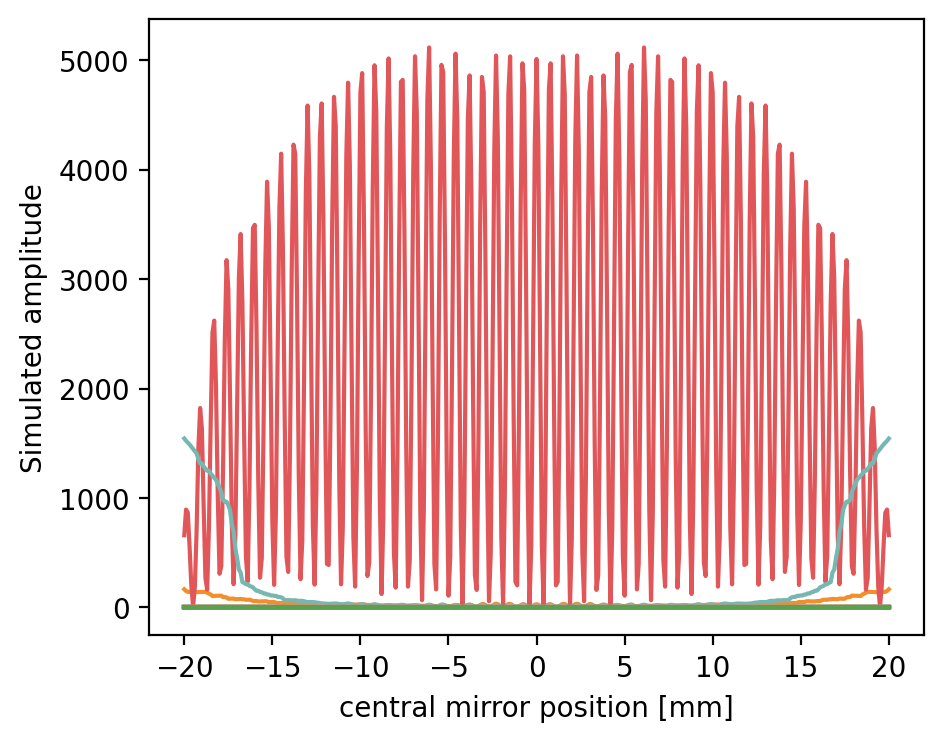

In [52]:
[plt.plot(mirror_positions, i) for i in interferograms]
plt.xlabel('central mirror position [mm]')
plt.ylabel('Simulated amplitude')
plt.show()

As expected, none of these really have any signal except the central interferogram. 

Now, let's compute the spectrum of this interferogram and infer the frequency shift:

initial frequency = 100
maximumum in data obtained at frequency 97.25685785536159
measured frequency from gaussian fit = 98.08387586591724
FWHM from gaussian fit = 3.68752929077144
frequency calibration factor =  1.019535567055916


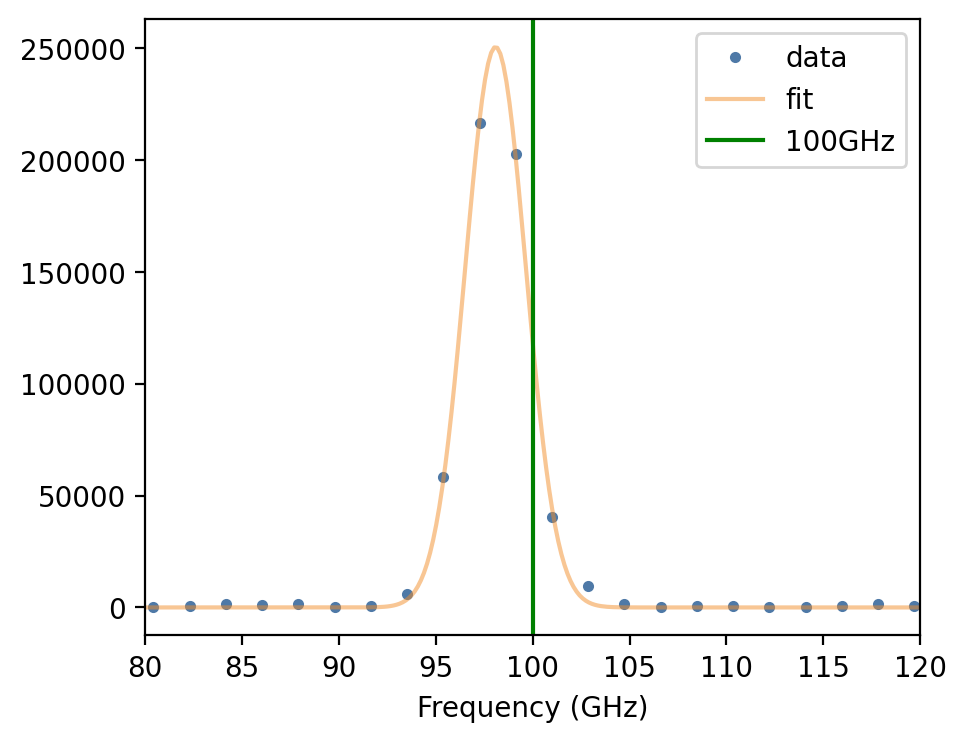

In [53]:
_, gaussian_diff, _ = interferogram_fitting.get_frequency_shift_and_peak_width(
    freq, interferograms[12], 0.1, print_vals=True, plot_vals=True)
print("frequency calibration factor = ", freq / (gaussian_diff * freq + freq))
plt.show()


So, for a centered point source and centered detector, the shift is exactly what we expect geometrically

## Amplitude transfer function

Now, let's compute how the amplitude of the measured spectrum changes vs frequency. There are two effectively equivalent ways to do this:

(1) Generate interferograms inside the desired frequency range, fit the amplitude of each from a gaussian, and plot the fitted amplitudes vs frequency

(2) Genreate an interferogram from a multi-frequency source and compute the spectrum. This requires a finer-spaced frequency grid to avoid discrete sampling effects.

In [54]:
amps = []
for freq in tqdm(np.arange(200, 300, 5)):
    indiv_freq_interferograms = np.sum(utils.get_and_combine_interferograms(
        [out], [freq],5, 5, 5.3, debug=False, weight_rays=True), axis=0)
    amp = interferogram_fitting.get_amplitude(indiv_freq_interferograms[12], 0.1)
    amps.append(amp)


full_freq_interferograms = np.sum(utils.get_and_combine_interferograms(
    [out], np.arange(200, 300, 0.1), 5, 5, 5.3, debug=False, weight_rays=True), axis=0)

100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:03<00:00,  5.52it/s]


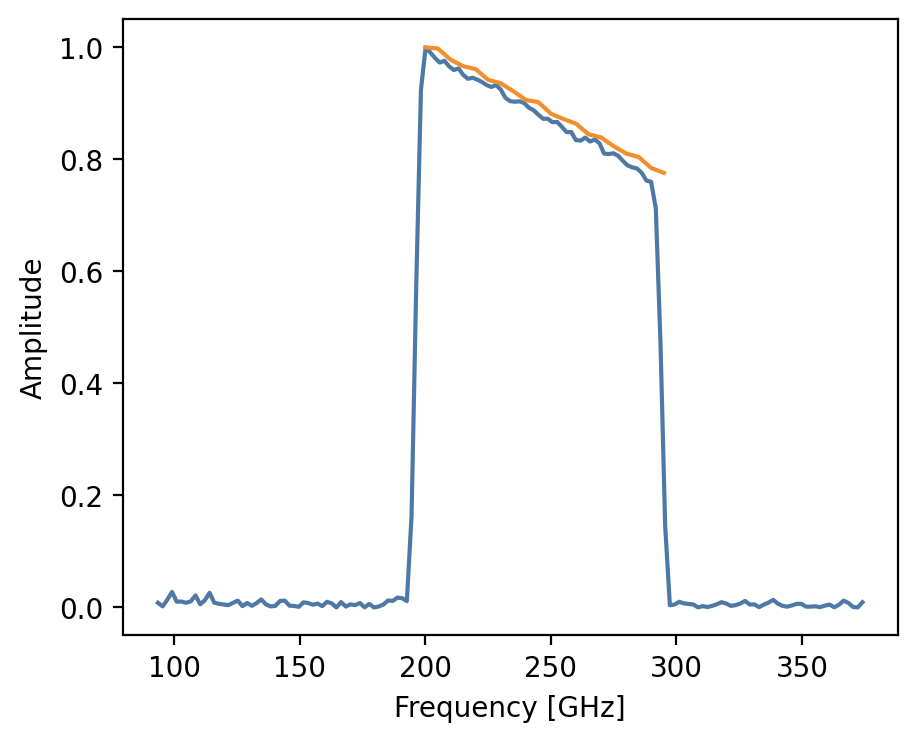

In [59]:
c = 300.
def normalize(x):
    return x / np.max(x)

freqs, fft = interferogram_fitting.generate_spectrum(full_freq_interferograms[12], 0.1)
plt.plot(c * freqs[50:], normalize(fft[50:]))
plt.plot(np.arange(200, 300, 5), normalize(np.array(amps)[:, 0]))
#plt.ylim(0, 1)
# plt.xlim(290, 305)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Amplitude')
plt.show()


We see this these produce equivalent transfer functions. In practice I like to do method (1) since it is much faster and already less noisy.